**Objective II - Selecting best model architecture**

In [53]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [54]:
with open("../src/experiments/results/objective_II/models_performance.json", "r") as file:
    data = json.load(file)

models = []
language_scores = defaultdict(list)

for model, results in data.items():
    total_model_score = 0
    for language, scores in results.items():
        language_scores[language].append(round(scores["val_f1"], 5))
        total_model_score += round(scores["val_f1"], 5)
    print("Model: {}".format(model))
    print("Avg. Score: {}".format(total_model_score / 6))
    print()
    models.append(model)

Model: BERT
Avg. Score: 0.8873366666666667

Model: BERT-CRF
Avg. Score: 0.90001

Model: BERT-Bilstm
Avg. Score: 0.7978866666666665

Model: BERT-Bilstm-CRF
Avg. Score: 0.8804966666666667



In [55]:
# How much better is BERT-CRF?
print(f"BERT-CRF is {(0.9 - 0.8873333333333333) / 0.8873333333333333 * 100} % better than BERT")
print(f"BERT-CRF is {(0.9 - 0.7978333333333333) / 0.7978333333333333 * 100} % better than BERT-BILSTM")
print(f"BERT-CRF is {(0.9 - 0.8805000000000001) / 0.8805000000000001 * 100} % better than BERT-BILSTM-CRF")

BERT-CRF is 1.4274981217130032 % better than BERT
BERT-CRF is 12.805514936285784 % better than BERT-BILSTM
BERT-CRF is 2.2146507666098763 % better than BERT-BILSTM-CRF


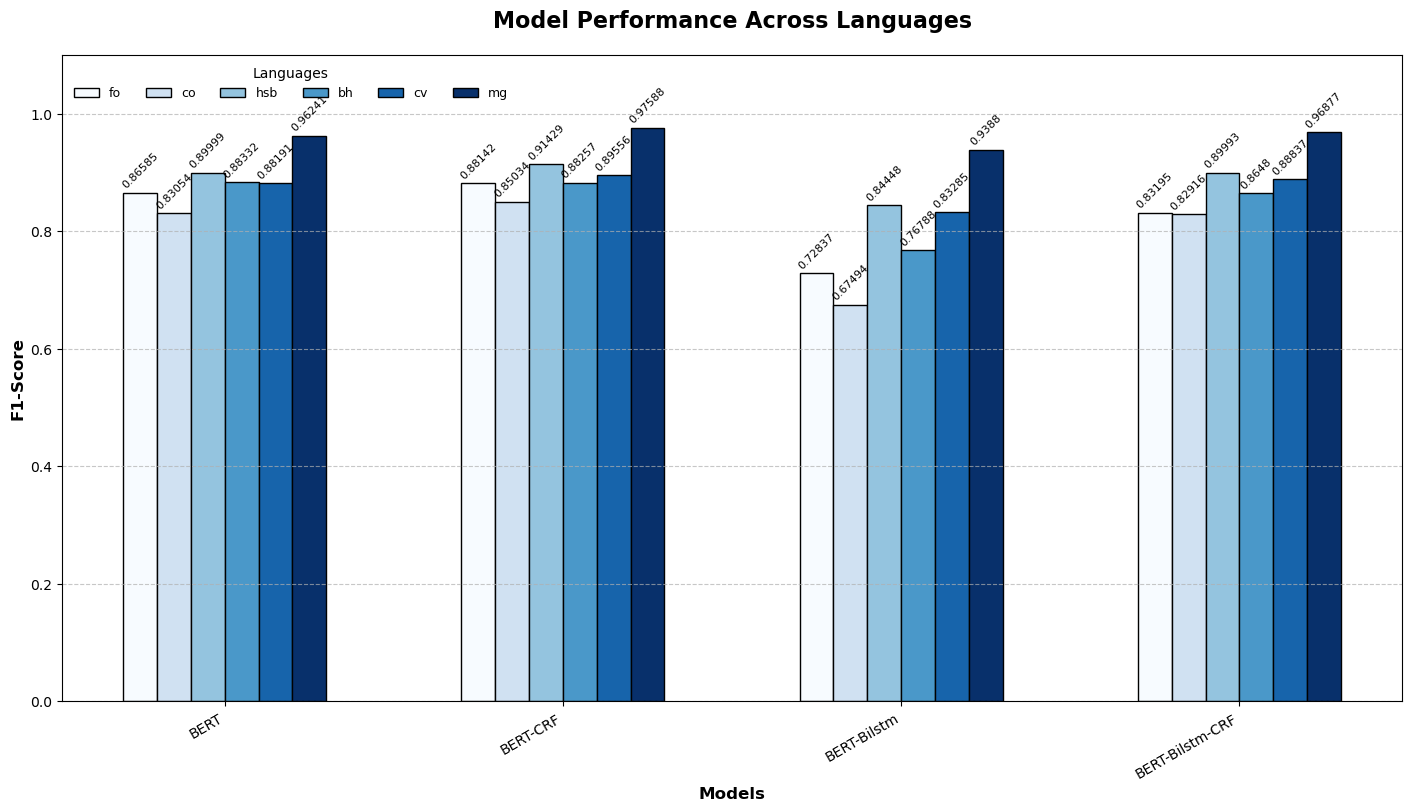

In [56]:
x = np.arange(len(models))
fig, ax = plt.subplots(layout="constrained", figsize=(14, 8))

width = 0.1
multiplier = -2

colors = plt.get_cmap("Blues", len(language_scores))

for idx, (language, scores) in enumerate(language_scores.items()):
    offset = width * multiplier
    rects = ax.bar(
        x + offset,
        scores,
        width,
        label=language,
        color=colors(idx),
        edgecolor='black'
    )
    ax.bar_label(rects, padding=2, fontsize=8, rotation=45)
    multiplier += 1

ax.set_ylabel("F1-Score", fontsize=12, weight="bold")
ax.set_xlabel("Models", fontsize=12, weight="bold")
ax.set_title("Model Performance Across Languages", fontsize=16, weight="bold", pad=20)
ax.set_xticks(x + width / 2, labels=models, fontsize=10, rotation=30, ha="right")
ax.set_ylim(0, 1.1)

ax.grid(axis="y", linestyle="--", alpha=0.7)

ax.legend(
    title="Languages",
    title_fontsize=10,
    fontsize=9,
    loc="upper left",
    ncols = 6,
    frameon=False
)

plt.show()

**Objective III - training baseline model**

In [57]:
with open("../src/experiments/results/objective_III/baseline_model_performance.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
baseline_language_scores = {}

total_model_score = 0
for language, scores in data.items():
    baseline_language_scores[language] = round(scores["val_f1"], 5)
    total_model_score += round(scores["val_f1"], 5)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo, Val-F1: 0.89083
Lang: co, Val-F1: 0.85126
Lang: hsb, Val-F1: 0.91975
Lang: bh, Val-F1: 0.89430
Lang: cv, Val-F1: 0.89381
Lang: mg, Val-F1: 0.97265

Model: BERT-CRF
Avg. Score: 0.9037666666666667



In [58]:
baseline_language_scores

{'fo': 0.89083,
 'co': 0.85126,
 'hsb': 0.91975,
 'bh': 0.8943,
 'cv': 0.89381,
 'mg': 0.97265}

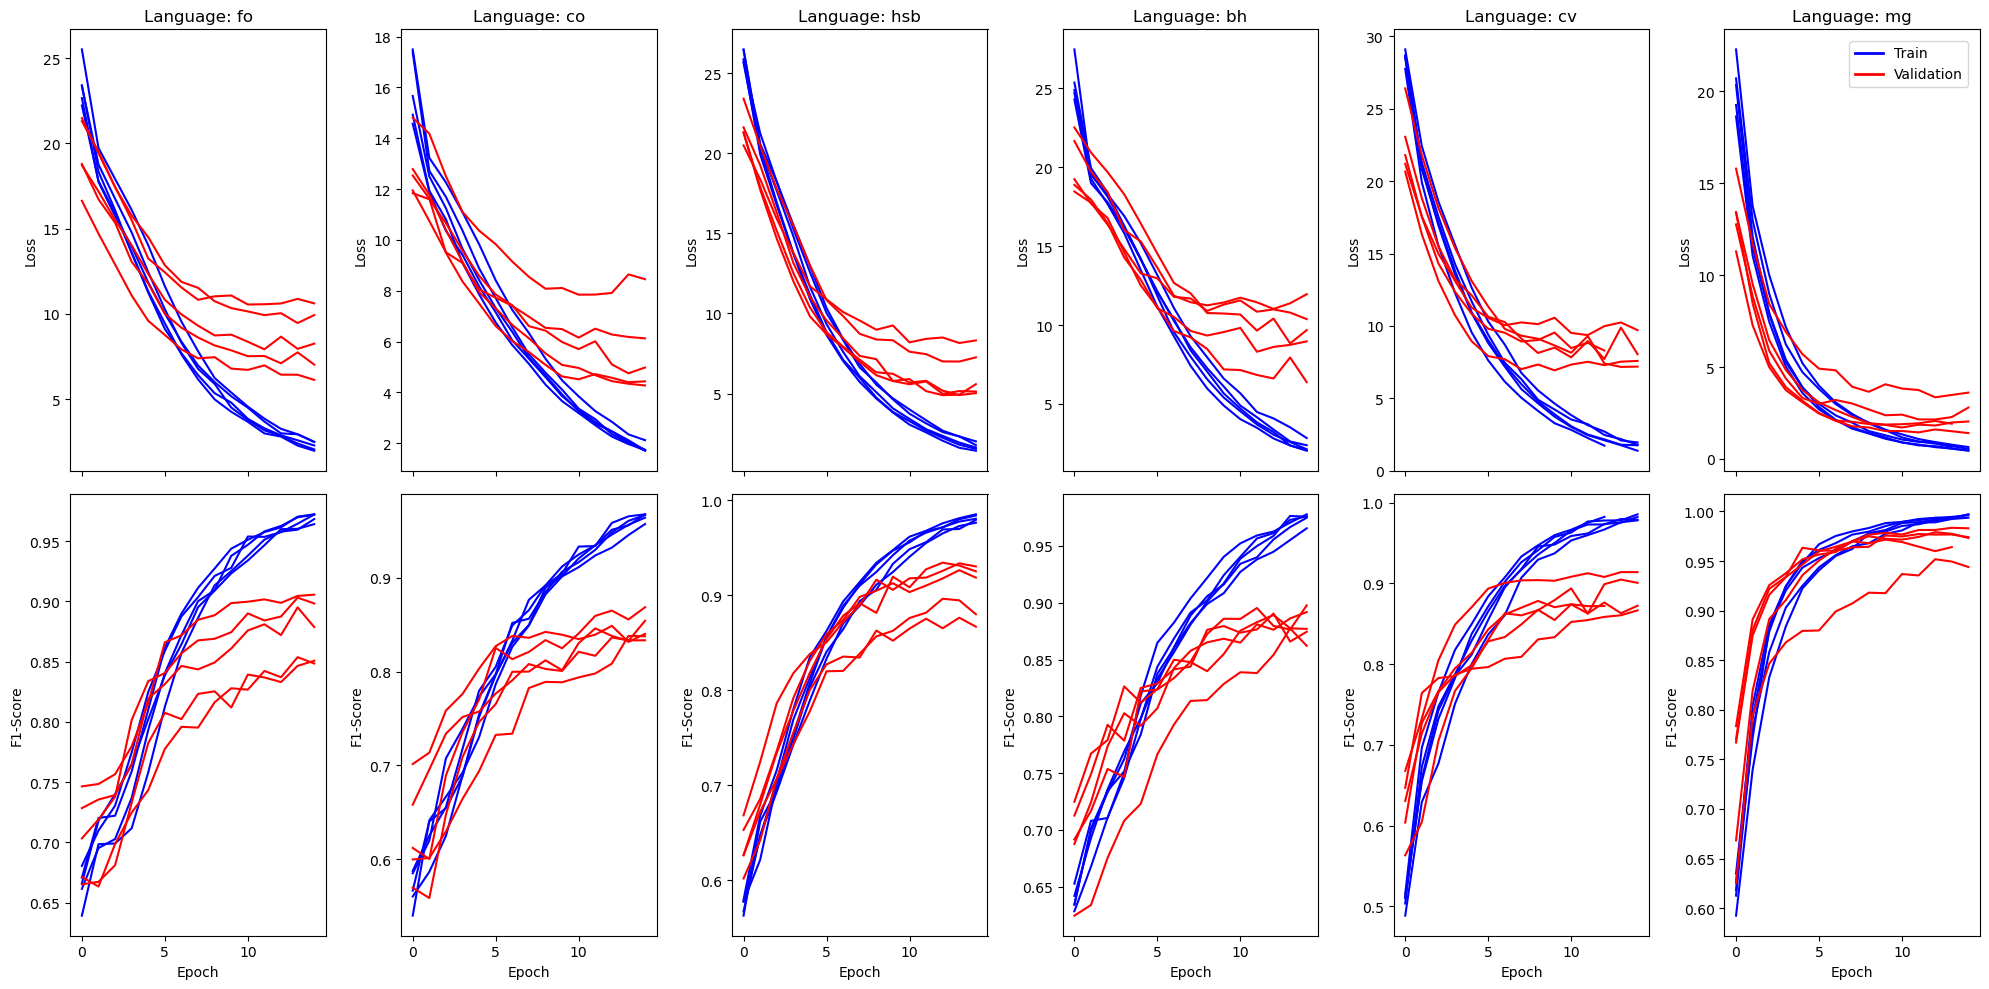

In [59]:
with open("../src/experiments/results/objective_III/baseline_model_logging.json", "r") as file:
    logging = json.load(file)

fig, axes = plt.subplots(2, 6, figsize=(20, 10), sharex=True)

for idx, (language_code, metrics) in enumerate(logging.items()):
    train_losses = metrics["train_losses"]
    val_losses = metrics["val_losses"]
    train_f1s = metrics["train_f1s"]
    val_f1s = metrics["val_f1s"]

    for item in train_losses:
        axes[0][idx].plot(item, color='blue')
    for item in val_losses:
        axes[0][idx].plot(item, color='red')
    for item in train_f1s:
        axes[1][idx].plot(item, color='blue')
    for item in val_f1s:
        axes[1][idx].plot(item, color='red')

    axes[0][idx].set_title(f"Language: {language_code}", fontsize=12)
    axes[0][idx].set_ylabel("Loss", fontsize=10)
    axes[1][idx].set_ylabel("F1-Score", fontsize=10)
    axes[1][idx].set_xlabel("Epoch", fontsize=10)

# Add legend
lines = [plt.Line2D([0], [0], color='blue', lw=2),
         plt.Line2D([0], [0], color='red', lw=2)]
labels = ['Train', 'Validation']
fig.legend(lines, labels, loc='upper right', fontsize=10, bbox_to_anchor=(0.99, 0.96))

plt.tight_layout()
plt.show()

**Objective IV - Cross-lingual transfer learning**

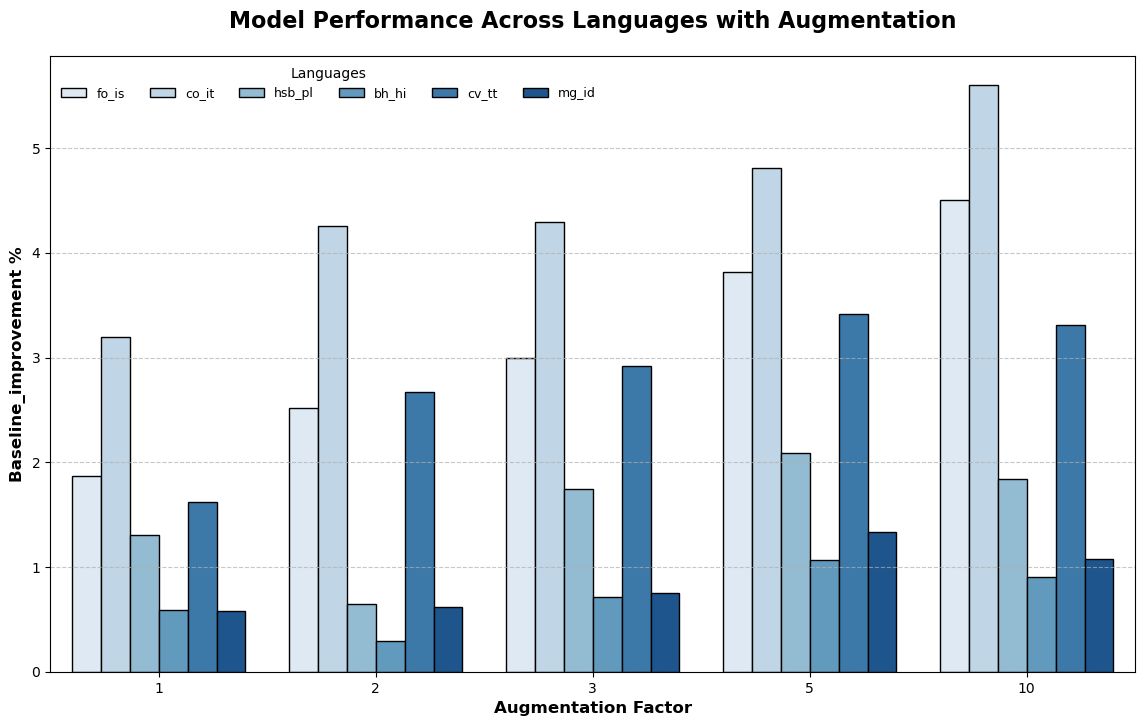

In [60]:
import seaborn as sns
import pandas as pd

import os
import re
from collections import defaultdict

lang_codes = {'fo_is': 'fo','co_it': 'co','hsb_pl': 'hsb','bh_hi': 'bh','cv_tt': 'cv','mg_id': 'mg'}
augmentation_data = defaultdict(dict)
augementation_factors = []

for filename in os.listdir("../src/experiments/results/objective_IV"):
    with open(f"../src/experiments/results/objective_IV/{filename}") as file:
        data = json.load(file)

        filename = filename.replace(".json", "")

        augementation_factor = int(re.search(r'\d+$', filename).group())
        augementation_factors.append(augementation_factor)

        for language, scores in data.items():
            augmentation_data[augementation_factor][language] = round(scores["val_f1"], 5)

# Prepare the data for seaborn
plot_data = []
for aug_factor, scores in augmentation_data.items():
    for language, score in scores.items():
        baseline_score = baseline_language_scores[lang_codes[language]]
        improvement = ((score - baseline_score) / baseline_score) * 100
        plot_data.append({'Augmentation Factor': aug_factor, 'Language': language, 'F1-Score': score, 'Baseline_improvement': improvement})

df_plot = pd.DataFrame(plot_data)

# Create the seaborn plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Augmentation Factor', y='Baseline_improvement', hue='Language', data=df_plot, palette='Blues', edgecolor="black")

plt.title('Model Performance Across Languages with Augmentation', fontsize=16, weight='bold', pad=20)
plt.xlabel('Augmentation Factor', fontsize=12, weight='bold')
plt.ylabel('Baseline_improvement %', fontsize=12, weight='bold')
plt.legend(title='Languages', title_fontsize=10, fontsize=9, loc='upper left', ncol=6, frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


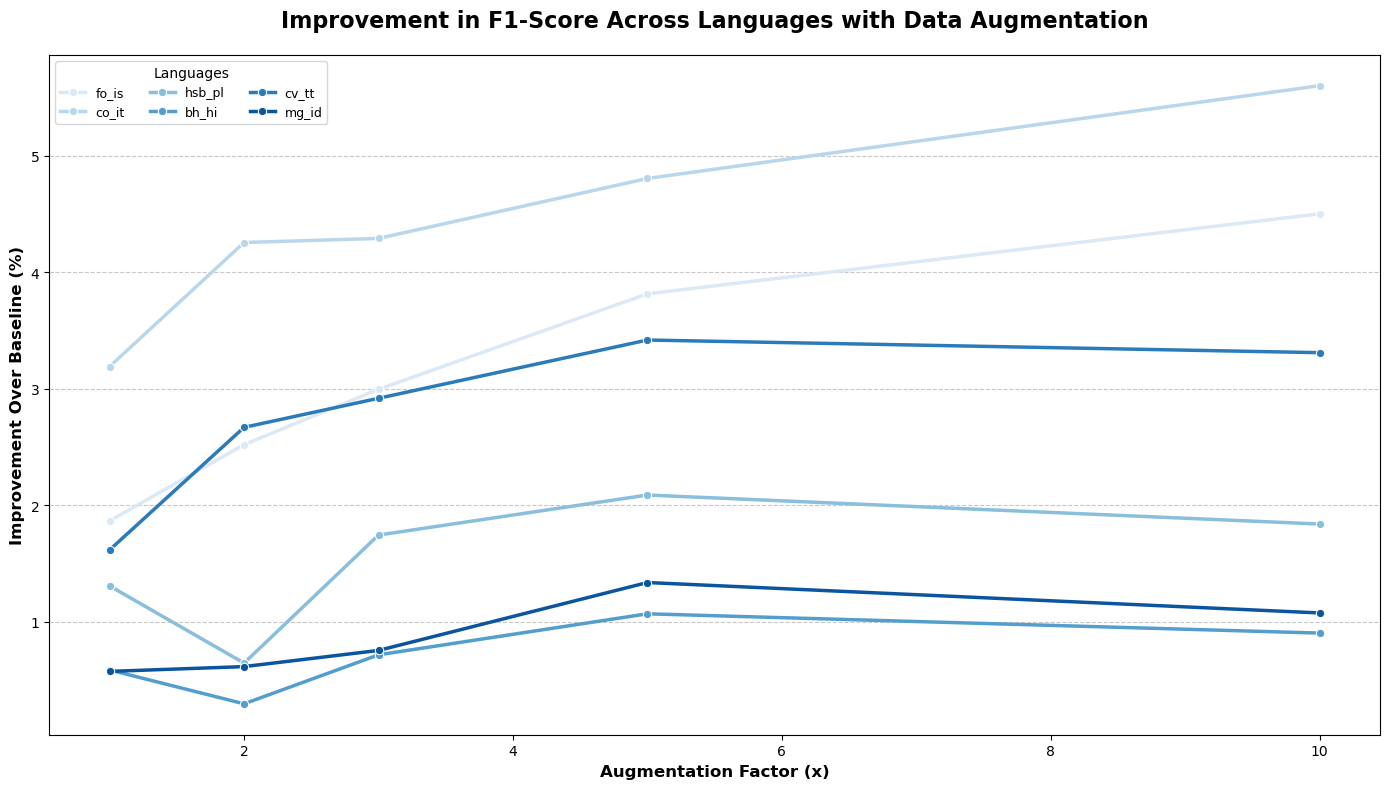

In [61]:
plt.figure(figsize=(14, 8))
sns.lineplot(x='Augmentation Factor', y='Baseline_improvement', hue='Language', data=df_plot, 
             palette='Blues', marker='o', linewidth=2.5)

plt.title('Improvement in F1-Score Across Languages with Data Augmentation', fontsize=16, weight='bold', pad=20)
plt.xlabel('Augmentation Factor (x)', fontsize=12, weight='bold')
plt.ylabel('Improvement Over Baseline (%)', fontsize=12, weight='bold')
plt.legend(title='Languages', title_fontsize=10, fontsize=9, loc='upper left', ncol=3, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [62]:
with open("../src/experiments/results/objective_IV/transfer_learning_performance1.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.90747
Lang: co_it, Val-F1: 0.87844
Lang: hsb_pl, Val-F1: 0.93179
Lang: bh_hi, Val-F1: 0.89956
Lang: cv_tt, Val-F1: 0.90828
Lang: mg_id, Val-F1: 0.97825

Model: BERT-CRF
Avg. Score: 0.9171666666666667



In [63]:
with open("../src/experiments/results/objective_IV/transfer_learning_performance2.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.91330
Lang: co_it, Val-F1: 0.88750
Lang: hsb_pl, Val-F1: 0.92570
Lang: bh_hi, Val-F1: 0.89696
Lang: cv_tt, Val-F1: 0.91768
Lang: mg_id, Val-F1: 0.97865

Model: BERT-CRF
Avg. Score: 0.92



In [64]:
with open("../src/experiments/results/objective_IV/transfer_learning_performance5.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.92483
Lang: co_it, Val-F1: 0.89218
Lang: hsb_pl, Val-F1: 0.93897
Lang: bh_hi, Val-F1: 0.90387
Lang: cv_tt, Val-F1: 0.92438
Lang: mg_id, Val-F1: 0.98567

Model: BERT-CRF
Avg. Score: 0.9283333333333333



In [65]:
with open("../src/experiments/results/objective_IV/transfer_learning_performance10.json", "r") as file:
    data = json.load(file)

model = "BERT-CRF"
language_scores = {}

total_model_score = 0
for language, scores in data.items():
    language_scores[language] = round(scores["val_f1"], 3)
    total_model_score += round(scores["val_f1"], 3)

    print(f"Lang: {language}, Val-F1: {scores['val_f1']:.5f}")

print("\nModel: {}".format(model))
print("Avg. Score: {}".format(total_model_score / 6))
print()

Lang: fo_is, Val-F1: 0.93095
Lang: co_it, Val-F1: 0.89896
Lang: hsb_pl, Val-F1: 0.93668
Lang: bh_hi, Val-F1: 0.90239
Lang: cv_tt, Val-F1: 0.92341
Lang: mg_id, Val-F1: 0.98313

Model: BERT-CRF
Avg. Score: 0.9291666666666667



In [66]:
(0.89896 - 0.85126) / 0.85126 * 100

5.603458402838141